In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

Load the Dataset

In [49]:
df = pd.read_csv("AirPassengers.csv")
df.columns = ["Month", "Passengers"]
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

Standardize the Data

In [50]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)


Sequence Creation


In [51]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_length = 12
X, y = create_sequences(scaled_data, sequence_length)

Reshape

In [52]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

Model Building

In [58]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0783
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0256
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0158
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0099
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0121
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0100
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0096
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0102
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0091
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0117
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0103
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0077
Epoch 13/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0080
Epoch 14/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0071
Epoch 15/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0097
Epoch 16/50
9/9 ━━━━━━━━━━━━━━━━━━

Forcasting Next Twelve Months

In [59]:
last_sequence = scaled_data[-sequence_length:]
forecast = []

input_seq = last_sequence.copy()
for _ in range(12):
    pred = model.predict(input_seq.reshape(1, sequence_length, 1), verbose=0)
    forecast.append(pred[0, 0])
    input_seq = np.append(input_seq[1:], [[pred[0, 0]]], axis=0)

Transforming Back To Original Scale

In [60]:
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))


Ploting The Result

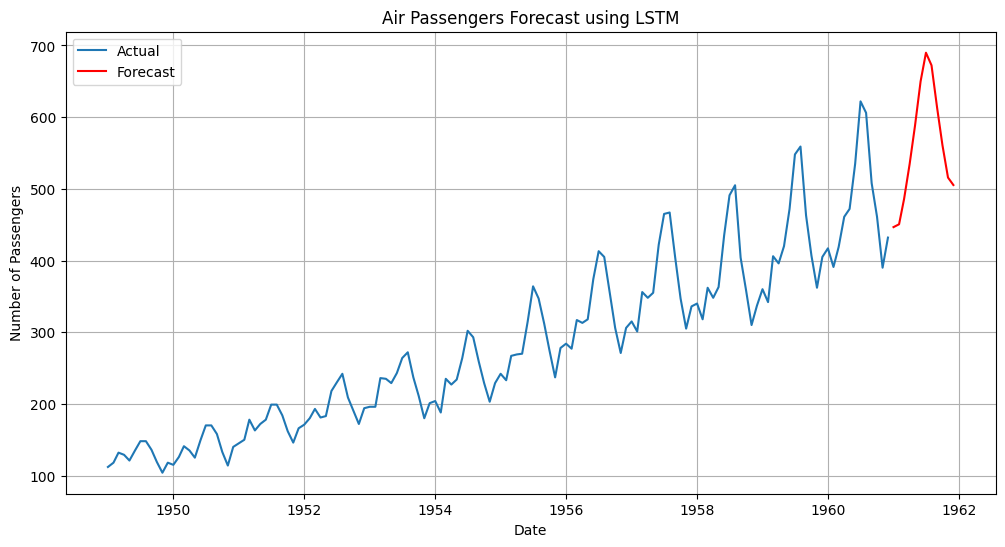

In [61]:
forecast_index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=["Forecast"])

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], label='Actual')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Forecast using LSTM')
plt.legend()
plt.grid(True)
plt.show()